In [1]:
import sys
sys.path.append('../src')

from preprocess import load_and_clean, encode, split
from explain import (
    load_explainer, plot_summary,
    plot_bar, explain_customer, plot_waterfall
)
import joblib
import pandas as pd

IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


In [2]:
# Carrega modelo e dados
model = joblib.load('../models/xgb_model.pkl')
feature_cols = joblib.load('../models/feature_columns.pkl')

df = load_and_clean('../data/telco_churn.csv')
df = encode(df)
_, X_test, _, y_test = split(df)

explainer = load_explainer(model, X_test)
print("Explainer carregado.")
ev = explainer.expected_value
if hasattr(ev,'__len__'):
    ev = ev[0]
print(f"Valor base (Expected value): {ev:.4f}")
# Este é o risco médio de churn no dataset — ponto de partida do waterfall

Explainer carregado.
Valor base (Expected value): -0.6230


In [3]:
import numpy as np

ev_logodds = explainer.expected_value
if hasattr(ev_logodds, '__len__'):
    ev_logodds = ev_logodds[0]

ev_prob = 1 / (1 + np.exp(-ev_logodds))
print(f"Expected value (log-odds): {ev_logodds:.4f}")
print(f"Expected value (probabilidade): {ev_prob:.4f}")

Expected value (log-odds): -0.6230
Expected value (probabilidade): 0.3491


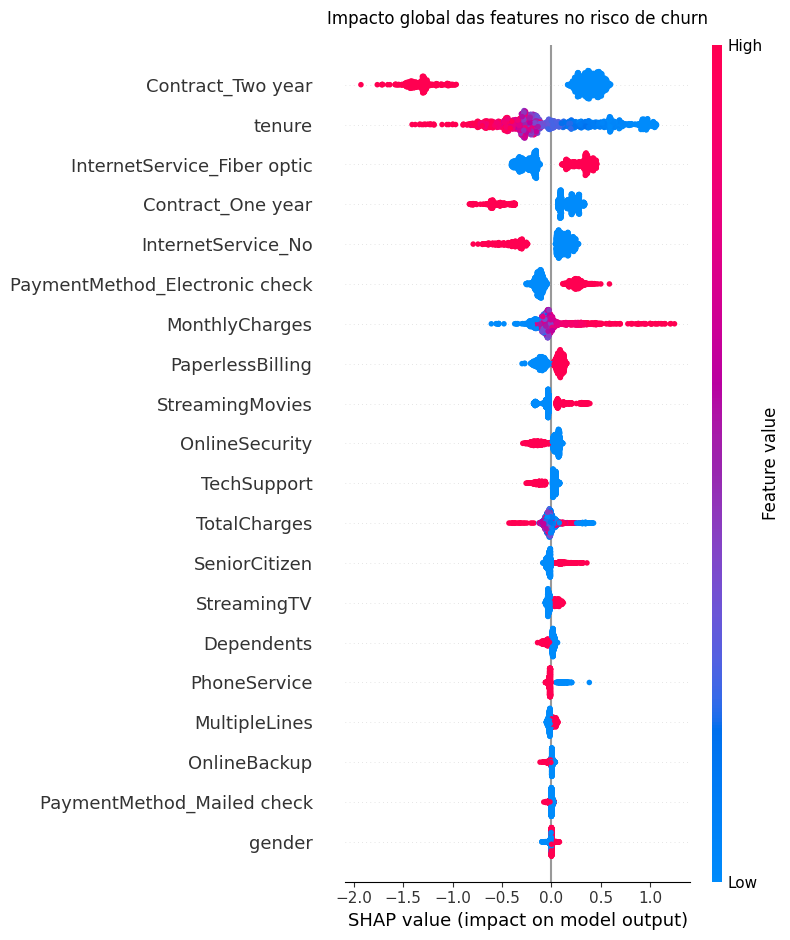

Summary plot salvo em assets/shap_summary.png


In [4]:
# Summary plot global — a imagem principal do README
shap_values = plot_summary(explainer, X_test)

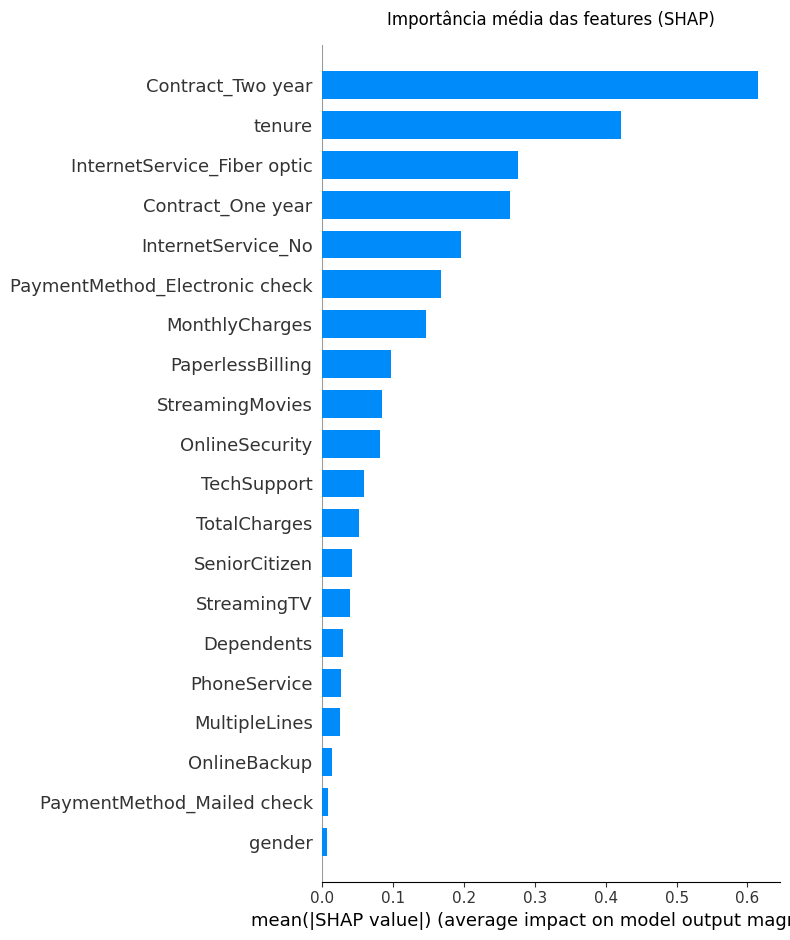

Bar plot salvo em assets/shap_bar.png


In [5]:
# Bar plot — ranking simples para não-técnicos
plot_bar(explainer, X_test)

In [6]:
# Teste com um cliente de ALTO risco
# Pega um cliente que o modelo previu churn com alta confiança
probas = model.predict_proba(X_test)[:, 1]
alto_risco_idx = probas.argmax()

cliente_alto = X_test.iloc[[alto_risco_idx]]
resultado = explain_customer(cliente_alto, model, explainer, feature_cols)

print(f"\nProbabilidade de churn: {resultado['probabilidade_churn']:.1%}")
print(f"Nível de risco: {resultado['nivel_risco']}")
print(f"\nTop fatores que aumentam o risco:")
for f in resultado['top_fatores']:
    sinal = '+' if f['contribuicao'] > 0 else ''
    print(f"  {f['feature']}: {sinal}{f['contribuicao']} (valor={f['valor']})")


Probabilidade de churn: 92.8%
Nível de risco: ALTO

Top fatores que aumentam o risco:
  tenure: +0.92 (valor=1)
  Contract_Two year: +0.4804 (valor=0)
  InternetService_Fiber optic: +0.3454 (valor=1)
  InternetService_No: +0.251 (valor=0)
  Contract_One year: +0.2276 (valor=0)


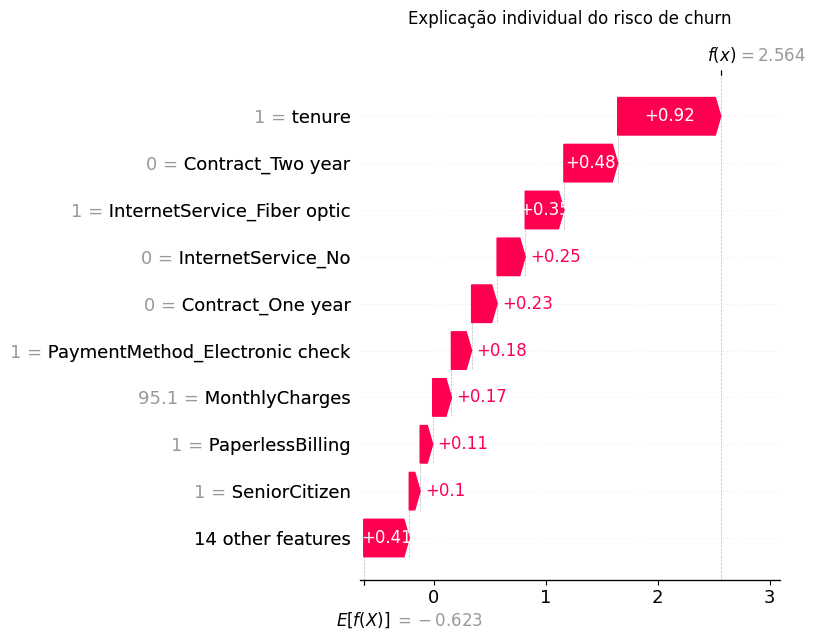

Waterfall plot salvo em ../assets/shap_waterfall_alto_risco.png


In [7]:
# Waterfall do cliente de alto risco — a imagem mais impactante
plot_waterfall(cliente_alto, explainer, feature_cols,
               save_path='../assets/shap_waterfall_alto_risco.png')

Probabilidade de churn: 2.7%
Nível de risco: BAIXO


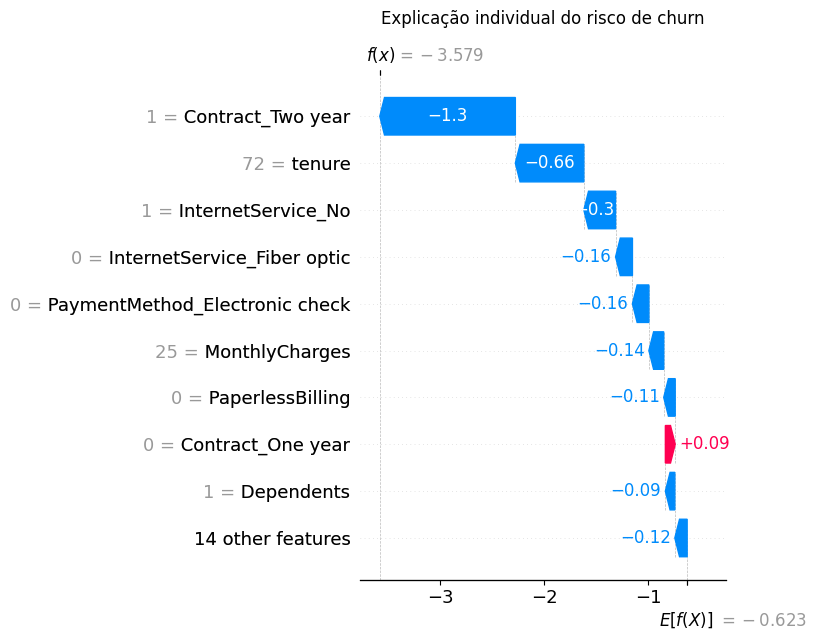

Waterfall plot salvo em ../assets/shap_waterfall_baixo_risco.png


In [8]:
# Contraste — cliente de BAIXO risco para comparar
baixo_risco_idx = probas.argmin()
cliente_baixo = X_test.iloc[[baixo_risco_idx]]

resultado_baixo = explain_customer(cliente_baixo, model, explainer, feature_cols)
print(f"Probabilidade de churn: {resultado_baixo['probabilidade_churn']:.1%}")
print(f"Nível de risco: {resultado_baixo['nivel_risco']}")

plot_waterfall(cliente_baixo, explainer, feature_cols,
               save_path='../assets/shap_waterfall_baixo_risco.png')